In [37]:
import pandas as pd

# Read the CSV file from GitHub
url_temp = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
url_torn = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_torn.csv"
url_hurrican = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_hurricane.csv"
url_typhoon = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.WP.list.v04r01.csv"
df_temp = pd.read_csv(url_temp)
df_torn = pd.read_csv(url_torn)
df_hurr = pd.read_csv(url_hurrican)
df_typh = pd.read_csv(url_typhoon)
print(df_temp.head())
print(df_torn .head())
print(df_hurr.head())
print(df_typh.head())



C:\Users\gregg\AppData\Local\Temp\ipykernel_23588\4275248124.py:11: DtypeWarning: Columns (1,2,8,9,14,19,20,23,24,142,143,144,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  df_typh = pd.read_csv(url_typhoon)


   Year  No_Smoothing  Lowess(30)
0  1880         -0.17       -0.21
1  1881         -0.09       -0.21
2  1882         -0.11       -0.21
3  1883         -0.17       -0.22
4  1884         -0.28       -0.22
    om    yr  mo  dy        date      time  tz  st  stf  stn  ...   len  wid  \
0  192  1950  10   1   10/1/1950  21:00:00   3  OK   40   23  ...  15.8   10   
1  193  1950  10   9   10/9/1950   2:15:00   3  NC   37    9  ...   2.0  880   
2  195  1950  11  20  11/20/1950   2:20:00   3  KY   21    1  ...   0.1   10   
3  196  1950  11  20  11/20/1950   4:00:00   3  KY   21    2  ...   0.1   10   
4  197  1950  11  20  11/20/1950   7:30:00   3  MS   28   14  ...   2.0   37   

   ns  sn  sg   f1  f2  f3  f4  fc  
0   1   1   1   25   0   0   0   0  
1   1   1   1   47   0   0   0   0  
2   1   1   1  177   0   0   0   0  
3   1   1   1  209   0   0   0   0  
4   1   1   1  101   0   0   0   0  

[5 rows x 29 columns]
       name  year  month  day  hour   lat  long               status  

In [39]:
#Temp clean up
import re
import pandas as pd
import numpy as np


# --- BEFORE: quick report ---
print("Dataset shape (before):", df_temp.shape)
print("Columns (before):", list(df_temp.columns))
print("\nMissing values per column (before):")
print(df_temp.isnull().sum())

# --- Renaming: add exactly one 'temp_' prefix and normalize names ---
def _normalize(name: str) -> str:
    # trim, lower, replace non-alphanumerics with underscore, collapse edges
    return re.sub(r'[^0-9a-zA-Z]+', '_', str(name).strip().lower()).strip('_')

def _ensure_temp_prefix(name: str) -> str:
    n = _normalize(name)
    # remove any existing 'temp_' at the start, then add exactly one
    if n.startswith("temp_"):
        n = n[len("temp_"):]
    return "temp_" + n

df_temp = df_temp.rename(columns=_ensure_temp_prefix)

# --- AFTER: report ---
print("\nDataset shape (after):", df_temp.shape)
print("Columns (after):", list(df_temp.columns))
print("\nMissing values per column (after):")
print(df_temp.isnull().sum())
df_temp

Dataset shape (before): (145, 3)
Columns (before): ['Year', 'No_Smoothing', 'Lowess(30)']

Missing values per column (before):
Year            0
No_Smoothing    0
Lowess(30)      0
dtype: int64

Dataset shape (after): (145, 3)
Columns (after): ['temp_year', 'temp_no_smoothing', 'temp_lowess_30']

Missing values per column (after):
temp_year            0
temp_no_smoothing    0
temp_lowess_30       0
dtype: int64


,temp_year,temp_no_smoothing,temp_lowess_30
0,1880,-0.17,-0.21
1,1881,-0.09,-0.21
2,1882,-0.11,-0.21
3,1883,-0.17,-0.22
4,1884,-0.28,-0.22
...,...,...,...
140,2020,1.01,0.93
141,2021,0.85,0.95
142,2022,0.89,0.97
143,2023,1.17,0.99


In [41]:
#tornado file cleanup

# --- Annual wide table: total + counts by magnitude (one row per year) ---

import pandas as pd
import numpy as np

# starting from df_torn (your raw tornado CSV)
tornado_unique = (
    df_torn.rename(columns=str.strip)
           .assign(
               yr = pd.to_numeric(df_torn["yr"], errors="coerce"),
               mag = pd.to_numeric(df_torn["mag"], errors="coerce")
           )
           .dropna(subset=["yr"])
           .astype({"yr": "int32"})
           .reset_index(drop=True)
)


# Bin magnitude: keep 0..5 as ints; everything else (NaN or -9) -> -1 "Unknown"
tornado_unique["mag_bin"] = np.where(
    (tornado_unique["mag"].notna()) & (tornado_unique["mag"] >= 0),
    tornado_unique["mag"].astype(int),
    -1
)

# Year (yr) × mag_bin counts; ensure all mag columns present
counts_wide = (
    tornado_unique
      .groupby(["yr", "mag_bin"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[-1, 0, 1, 2, 3, 4, 5], fill_value=0)
      .rename(columns={
          -1: "Mag_Unknown",
           0: "Mag0", 1: "Mag1", 2: "Mag2", 3: "Mag3", 4: "Mag4", 5: "Mag5"
      })
      .reset_index(names="Year")
)

# Totals
counts_wide["Total_Tornadoes"] = (
    counts_wide[["Mag_Unknown","Mag0","Mag1","Mag2","Mag3","Mag4","Mag5"]].sum(axis=1)
)
counts_wide["Total_Known"] = (
    counts_wide[["Mag0","Mag1","Mag2","Mag3","Mag4","Mag5"]].sum(axis=1)
)

# Optional: sort and reorder columns
counts_wide = counts_wide.sort_values("Year").loc[:, [
    "Year", "Total_Tornadoes", "Total_Known",
    "Mag_Unknown", "Mag0", "Mag1", "Mag2", "Mag3", "Mag4", "Mag5"
]].reset_index(drop=True)

counts_wide.head()

import re

torn_final = counts_wide.rename(
    columns=lambda c: "torn_" + re.sub(r'[^0-9a-zA-Z]+', '_', str(c).strip().lower()).strip('_')
)

# Quick check
print(list(torn_final.columns))

torn_final



['torn_year', 'torn_total_tornadoes', 'torn_total_known', 'torn_mag_unknown', 'torn_mag0', 'torn_mag1', 'torn_mag2', 'torn_mag3', 'torn_mag4', 'torn_mag5']


mag_bin,torn_year,torn_total_tornadoes,torn_total_known,torn_mag_unknown,torn_mag0,torn_mag1,torn_mag2,torn_mag3,torn_mag4,torn_mag5
0,1950,206,206,0,16,86,71,26,7,0
1,1951,261,261,0,49,100,84,23,5,0
2,1952,246,246,0,32,82,72,40,20,0
3,1953,442,442,0,66,160,143,46,22,5
4,1954,570,570,0,91,226,193,49,11,0
...,...,...,...,...,...,...,...,...,...,...
70,2020,1114,1007,107,468,419,95,19,6,0
71,2021,1364,1160,204,574,447,110,23,6,0
72,2022,1169,1017,152,405,458,126,21,7,0
73,2023,1361,1092,269,455,463,136,36,2,0


In [43]:
#hurrican cleanup


import re
import pandas as pd
import numpy as np

# ---------- LOAD ----------
df_hurr = pd.read_csv(url_hurrican)
df_hurr.columns = df_hurr.columns.str.strip()

# ---------- ALIASES: map different source column names to a standard set ----------
lower_map = {c.lower(): c for c in df_hurr.columns}
aliases = {
    "name":     ["name", "storm_name"],
    "year":     ["year", "season"],
    "status":   ["status", "storm_status"],
    "category": ["category", "usa_sshs", "sshs", "saffir_simpson"],
}

chosen = {}
for target, options in aliases.items():
    for opt in options:
        if opt in lower_map:
            chosen[target] = lower_map[opt]
            break

required = {"name", "year", "status", "category"}
missing_targets = [t for t in required if t not in chosen]
if missing_targets:
    raise KeyError(
        f"Could not find columns for: {missing_targets}. "
        f"Available columns: {list(df_hurr.columns)}"
    )

# ---------- TRIM & STANDARDIZE ----------
keep = [chosen[k] for k in ["name", "year", "status", "category"]]
out = (
    df_hurr[keep]
      .rename(columns={
          chosen["name"]: "name",
          chosen["year"]: "year",
          chosen["status"]: "status",
          chosen["category"]: "category",
      })
)

# Dtypes
out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
out["category"] = pd.to_numeric(out["category"], errors="coerce")  # keep NaN for unrated

# ---------- FILTER TO HURRICANES ----------
status_norm = out["status"].astype(str).str.strip().str.lower()
is_hurricane_status = (
    status_norm.str.contains("hurrican", na=False) |  # 'hurricane' / 'hurricanes'
    status_norm.isin({"hu", "h"})                     # code forms
)
is_hurricane_category = out["category"].between(1, 5, inclusive="both")
is_hurricane = is_hurricane_status & (is_hurricane_category | out["category"].isna())
hurr = out.loc[is_hurricane].copy()

# ---------- ONE ROW PER (year, name) AT MAX CATEGORY ----------
idx = (
    hurr.assign(_cat=hurr["category"].fillna(-1))  # -1 so NaN never wins max
        .groupby(["year", "name"])["_cat"]
        .idxmax()
)
top_per_storm = hurr.loc[idx].reset_index(drop=True)

# Clean category to Int64 (only 1..5)
cat_clean = pd.to_numeric(top_per_storm["category"], errors="coerce").astype("Int64")
cat_clean = cat_clean.where(cat_clean.between(1, 5), pd.NA)
top_per_storm = top_per_storm.assign(category=cat_clean)

# ---------- YEARLY TOTALS ----------
year_total = (
    top_per_storm.groupby("year", as_index=False)
                 .size()
                 .rename(columns={"year": "Year", "size": "Total_Hurricanes"})
)

# ---------- PER-CATEGORY COUNTS (Cat_1..Cat_5) ----------
cat_cols = [1, 2, 3, 4, 5]
year_cat = (
    top_per_storm.dropna(subset=["category"])
                 .groupby(["year", "category"], as_index=False)
                 .size()
                 .pivot(index="year", columns="category", values="size")
                 .reindex(columns=cat_cols, fill_value=0)  # ensure all cat columns
                 .reset_index()                            # bring 'year' back
)

# Fill and cast only category columns; rename nicely
for c in cat_cols:
    if c in year_cat.columns:
        year_cat[c] = year_cat[c].fillna(0).astype(int)

year_cat = (
    year_cat
        .rename(columns={c: f"Cat_{c}" for c in cat_cols})
        .rename(columns={"year": "Year"})
        .sort_values("Year")
        .reset_index(drop=True)
)

# ---------- MERGE TOTALS + CATEGORY COLUMNS ----------
hurr_year = (
    year_total.merge(year_cat, on="Year", how="left")
              .fillna(0)
)

# Make sure Cat_* are ints after the merge
for c in [f"Cat_{k}" for k in cat_cols]:
    if c in hurr_year.columns:
        hurr_year[c] = hurr_year[c].astype(int)

hurr_year = (
    hurr_year[["Year", "Total_Hurricanes", "Cat_1", "Cat_2", "Cat_3", "Cat_4", "Cat_5"]]
             .sort_values("Year")
             .reset_index(drop=True)
)

# ---------- ADD 'hurr_' PREFIX TO ALL OUTPUT COLUMNS ----------
def _hurr_prefix(name: str) -> str:
    n = re.sub(r'[^0-9a-zA-Z]+', '_', str(name).strip().lower()).strip('_')  # normalize
    n = re.sub(r'^(?:hurr_)+', '', n)  # prevent double prefix
    return f"hurr_{n}"

hurr_year = hurr_year.rename(columns=_hurr_prefix)

print(hurr_year.head())

   hurr_year  hurr_total_hurricanes  hurr_cat_1  hurr_cat_2  hurr_cat_3  \
0       1975                      6           1           2           2   
1       1976                      6           2           2           2   
2       1977                      5           4           0           0   
3       1978                      5           2           1           0   
4       1979                      5           2           1           0   

   hurr_cat_4  hurr_cat_5  
0           1           0  
1           0           0  
2           0           1  
3           2           0  
4           1           1  


In [45]:
###typhoon cleanup
# --- Load only what we need for filtering/deriving peak SSHS ---
usecols = ["SID","NAME","SEASON","BASIN","ISO_TIME","USA_WIND","WMO_WIND","USA_SSHS"]
df_typh = pd.read_csv(url_typhoon, usecols=usecols, low_memory=False)

# Coerce types
df_typh["SEASON"]   = pd.to_numeric(df_typh["SEASON"], errors="coerce").astype("Int64")
df_typh["USA_WIND"] = pd.to_numeric(df_typh["USA_WIND"], errors="coerce")
df_typh["WMO_WIND"] = pd.to_numeric(df_typh["WMO_WIND"], errors="coerce")
df_typh["USA_SSHS"] = pd.to_numeric(df_typh["USA_SSHS"], errors="coerce")
df_typh["ISO_TIME"] = pd.to_datetime(df_typh["ISO_TIME"], errors="coerce", utc=True)

# Filter: West Pacific + years
df_typh = df_typh[(df_typh["BASIN"] == "WP") & (df_typh["SEASON"].between(1975, 2024))].copy()

# Keep only storms that ever reached typhoon intensity (>= 64 kt by USA or WMO wind)
def reached_typhoon(g):
    return bool((g["USA_WIND"] >= 64).any() or (g["WMO_WIND"] >= 64).any())

ty_tracks = (
    df_typh.groupby("SID", group_keys=False)
           .filter(reached_typhoon)
           .sort_values(["SID","ISO_TIME"])
           .reset_index(drop=True)
)

# Helper: knots -> Saffir–Simpson category
def ss_cat(k):
    if pd.isna(k): return np.nan
    k = float(k)
    return 5 if k>=137 else 4 if k>=113 else 3 if k>=96 else 2 if k>=83 else 1 if k>=64 else 0

# Per-storm maxima
per_storm = (
    ty_tracks.groupby(["SID","NAME","SEASON"], as_index=False)
             .agg(max_usa_wind=("USA_WIND","max"),
                  max_wmo_wind=("WMO_WIND","max"),
                  max_usa_sshs=("USA_SSHS","max"))
)

# Prefer reported USA_SSHS; if NaN, derive from winds (USA then WMO)
per_storm["SSHS"] = per_storm["max_usa_sshs"]
m = per_storm["SSHS"].isna()
per_storm.loc[m, "SSHS"] = per_storm.loc[m, "max_usa_wind"].apply(ss_cat)
m = per_storm["SSHS"].isna()
per_storm.loc[m, "SSHS"] = per_storm.loc[m, "max_wmo_wind"].apply(ss_cat)

# Final trimmed table: only the columns you asked for
typhoon_simple = (
    per_storm.loc[:, ["NAME","SEASON","SSHS"]]
             .sort_values(["SEASON","NAME"])
             .reset_index(drop=True)
)

typhoon_simple


# --- One row per year with counts by SSHS category ---

# Ensure SSHS is integer categories 0..5 (drop NaN if any slipped through)
typhoon_simple["SSHS"] = pd.to_numeric(typhoon_simple["SSHS"], errors="coerce")

year_cat = (
    typhoon_simple
      .dropna(subset=["SSHS"])
      .assign(SSHS=lambda d: d["SSHS"].astype(int))
      .groupby(["SEASON", "SSHS"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[0,1,2,3,4,5], fill_value=0)   # ensure all category columns exist
      .rename(columns={0:"Cat0", 1:"Cat1", 2:"Cat2", 3:"Cat3", 4:"Cat4", 5:"Cat5"})
      .reset_index()
      .sort_values("SEASON")
)

# Optional: helpful totals
year_cat["Total_Typhoons"] = year_cat[["Cat0","Cat1","Cat2","Cat3","Cat4","Cat5"]].sum(axis=1)
year_cat["Major_Cat35"]    = year_cat[["Cat3","Cat4","Cat5"]].sum(axis=1)

# Reorder columns (Season first)
cols = ["SEASON","Total_Typhoons","Major_Cat35","Cat0","Cat1","Cat2","Cat3","Cat4","Cat5"]
year_cat = year_cat.loc[:, cols]

year_cat.head()

import re
typh_final = year_cat.rename(columns=lambda c: (
    "typh_" + re.sub(r'[^0-9a-zA-Z]+', '_', str(c).strip().lower()).strip('_')
    if not str(c).lower().startswith("hurr_")
    else str(c)
))

typh_final





C:\Users\gregg\AppData\Local\Temp\ipykernel_23588\2456797558.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_typh["ISO_TIME"] = pd.to_datetime(df_typh["ISO_TIME"], errors="coerce", utc=True)


SSHS,typh_season,typh_total_typhoons,typh_major_cat35,typh_cat0,typh_cat1,typh_cat2,typh_cat3,typh_cat4,typh_cat5
0,1975,14,5,0,6,3,1,3,1
1,1976,14,9,0,5,0,1,7,1
2,1977,11,4,0,4,3,1,3,0
3,1978,15,3,0,8,4,1,1,1
4,1979,14,8,0,2,4,4,2,2
5,1980,16,9,1,3,3,5,3,1
6,1981,16,6,0,5,5,2,3,1
7,1982,19,12,0,4,3,6,4,2
8,1983,13,6,1,5,1,0,3,3
9,1984,17,9,1,6,1,2,6,1


In [46]:
#joining all files

import pandas as pd
import numpy as np

def _prep_year_key(df, candidates):
    """Rename the first existing candidate to 'Year', coerce to Int64, dedupe per year."""
    found = None
    for c in candidates:
        if c in df.columns:
            found = c
            break
    if found is None:
        raise KeyError(f"None of the candidate year columns {candidates} found in: {list(df.columns)}")
    out = df.rename(columns={found: "Year"}).copy()
    out["Year"] = pd.to_numeric(out["Year"], errors="coerce").astype("Int64")
    out = out.dropna(subset=["Year"]).drop_duplicates(subset=["Year"], keep="last")
    return out

# 1) Normalize each table's join key to 'Year'
temp_k = _prep_year_key(df_temp,   ["temp_year", "year", "Year"])
torn_k = _prep_year_key(torn_final,["torn_year", "year", "Year"])
hurr_k = _prep_year_key(hurr_year, ["hurr_year", "year", "Year"])
typh_k = _prep_year_key(typh_final,["typh_season", "typh_Season", "season", "Season", "year", "Year"])

# 2) Merge (outer to keep all years present in any table)
merged = (
    temp_k.merge(torn_k, on="Year", how="outer", suffixes=(None, None))
          .merge(hurr_k, on="Year", how="outer")
          .merge(typh_k, on="Year", how="outer")
          .sort_values("Year")
          .reset_index(drop=True)
)

# 3) Optional: make sure non-Year numeric cols are numbers (won’t break strings)
for col in merged.columns:
    if col != "Year":
        merged[col] = pd.to_numeric(merged[col], errors="ignore")

# 4) Optional: fill NaNs for count-like columns with 0 (skip temp_* columns if you prefer)
count_like = [c for c in merged.columns if c != "Year" and not c.startswith("temp_")]
merged[count_like] = merged[count_like].fillna(0)

# 5) Put Year first, keep existing prefixed columns afterwards
cols = ["Year"] + [c for c in merged.columns if c != "Year"]
merged = merged.loc[:, cols]



merged = merged[pd.to_numeric(merged["Year"], errors="coerce").ge(1975)].copy()
merged = merged.sort_values("Year").reset_index(drop=True)

merged.head()
merged

C:\Users\gregg\AppData\Local\Temp\ipykernel_23588\1706304301.py:38: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  merged[col] = pd.to_numeric(merged[col], errors="ignore")


,Year,temp_no_smoothing,temp_lowess_30,torn_total_tornadoes,torn_total_known,torn_mag_unknown,torn_mag0,torn_mag1,torn_mag2,torn_mag3,...,hurr_cat_4,hurr_cat_5,typh_total_typhoons,typh_major_cat35,typh_cat0,typh_cat1,typh_cat2,typh_cat3,typh_cat4,typh_cat5
0,1975,-0.01,0.11,924.0,924.0,0.0,307.0,378.0,194.0,34.0,...,1.0,0.0,14.0,5.0,0.0,6.0,3.0,1.0,3.0,1.0
1,1976,-0.10,0.12,848.0,848.0,0.0,241.0,362.0,174.0,54.0,...,0.0,0.0,14.0,9.0,0.0,5.0,0.0,1.0,7.0,1.0
2,1977,0.18,0.13,861.0,861.0,0.0,236.0,420.0,143.0,48.0,...,0.0,1.0,11.0,4.0,0.0,4.0,3.0,1.0,3.0,0.0
3,1978,0.07,0.15,802.0,802.0,0.0,338.0,318.0,111.0,28.0,...,2.0,0.0,15.0,3.0,0.0,8.0,4.0,1.0,1.0,1.0
4,1979,0.16,0.16,865.0,865.0,0.0,359.0,342.0,120.0,31.0,...,1.0,1.0,14.0,8.0,0.0,2.0,4.0,4.0,2.0,2.0
5,1980,0.26,0.17,876.0,876.0,0.0,267.0,408.0,162.0,34.0,...,0.0,1.0,16.0,9.0,1.0,3.0,3.0,5.0,3.0,1.0
6,1981,0.32,0.18,786.0,786.0,0.0,283.0,320.0,153.0,23.0,...,1.0,0.0,16.0,6.0,0.0,5.0,5.0,2.0,3.0,1.0
7,1982,0.14,0.20,1066.0,1066.0,0.0,374.0,423.0,193.0,65.0,...,1.0,0.0,19.0,12.0,0.0,4.0,3.0,6.0,4.0,2.0
8,1983,0.31,0.21,938.0,938.0,0.0,350.0,376.0,149.0,59.0,...,0.0,0.0,13.0,6.0,1.0,5.0,1.0,0.0,3.0,3.0
9,1984,0.16,0.23,925.0,925.0,0.0,373.0,360.0,128.0,42.0,...,1.0,0.0,17.0,9.0,1.0,6.0,1.0,2.0,6.0,1.0


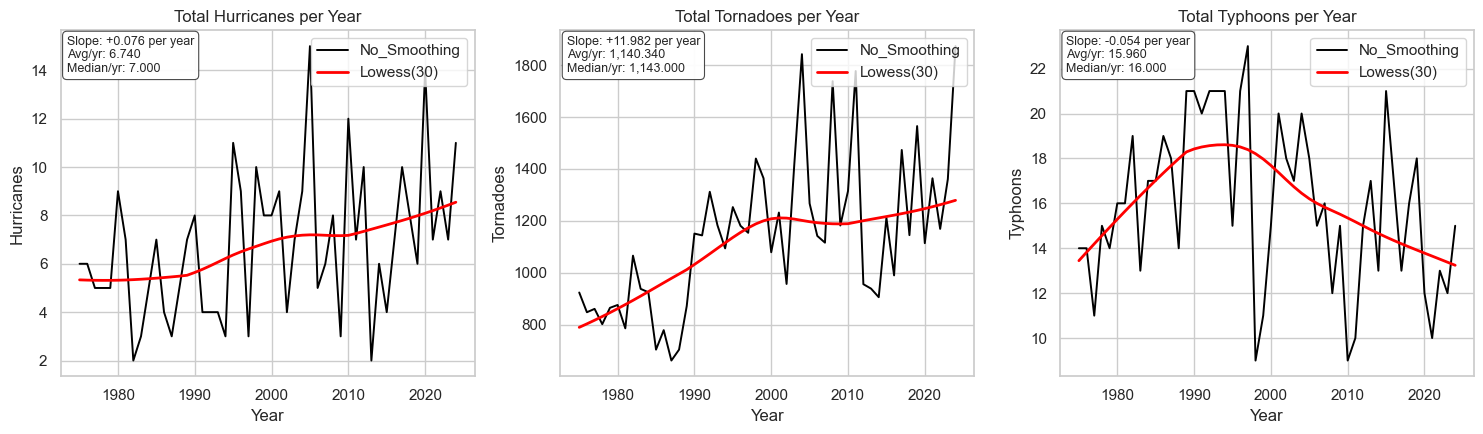

In [49]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# ===== Helpers ===============================================================
def pick_col(df, candidates):
    """Return the first column name that exists in df from candidates."""
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found. Available: {list(df.columns)}")

def lowess_series(x, y, years_span=30):
    """LOWESS smoother using a ~years_span window."""
    mask = np.isfinite(x) & np.isfinite(y)
    xs, ys = x[mask], y[mask]
    out = np.full_like(x, np.nan, dtype=float)
    if len(xs) >= 3:
        frac = min(1.0, years_span / max(len(np.unique(xs)), 1))
        out[mask] = lowess(ys, xs, frac=frac, return_sorted=False)
    return out

def add_trend_and_stats(ax, x, y):
    """Add linear trend line and a stats box (Slope / Avg / Median)."""
    m, b = np.polyfit(x, y, 1)                 # slope & intercept
    xx = np.array([x.min(), x.max()], float)
   # ax.plot(xx, m*xx + b, color="0.25", lw=1.2, alpha=0.9)

    txt = (
        f"Slope: {m:+.3f} per year\n"
        f"Avg/yr: {np.nanmean(y):,.3f}\n"
        f"Median/yr: {np.nanmedian(y):,.3f}"
    )
    ax.text(
        0.015, 0.985, txt,
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", lw=0.8, alpha=0.95),
        zorder=10,
    )

def plot_with_lowess(ax, year, series, title, ylabel):
    """One panel: black raw line, red LOWESS(30), gray trend, stats box."""
    year = pd.to_numeric(year, errors="coerce").to_numpy(float)
    series = pd.to_numeric(series, errors="coerce").to_numpy(float)
    mask = np.isfinite(year) & np.isfinite(series)
    x, y = year[mask], series[mask]

    # raw series + LOWESS
    ax.plot(x, y, color="black", lw=1.4, label="No_Smoothing")
    lo = lowess_series(x, y, years_span=30)
    ax.plot(x, lo[mask], color="red", lw=2.0, label="Lowess(30)")

    # linear trend + stats
    add_trend_and_stats(ax, x, y)

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper right", frameon=True)

# ===== Build data from `merged` =============================================
sns.set_theme(style="whitegrid")

df = merged.copy()
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df[df["Year"] >= 1975].sort_values("Year").reset_index(drop=True)

#col_temp = pick_col(df, ["temp_no_smoothing", "No_Smoothing"])
col_hurr = pick_col(df, ["hurr_total_hurricanes", "Total_Hurricanes"])
col_torn = pick_col(df, ["torn_total_tornadoes", "Total_Tornadoes"])
col_typh = pick_col(df, ["typh_total_typhoons", "Total_Typhoons"])

# ===== Plot 2×2 grid ========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)

plot_with_lowess(axes[0], df["Year"], df[col_hurr], "Total Hurricanes per Year", "Hurricanes")
plot_with_lowess(axes[1], df["Year"], df[col_torn], "Total Tornadoes per Year", "Tornadoes")
plot_with_lowess(axes[2], df["Year"], df[col_typh], "Total Typhoons per Year", "Typhoons")

plt.tight_layout()
plt.show()



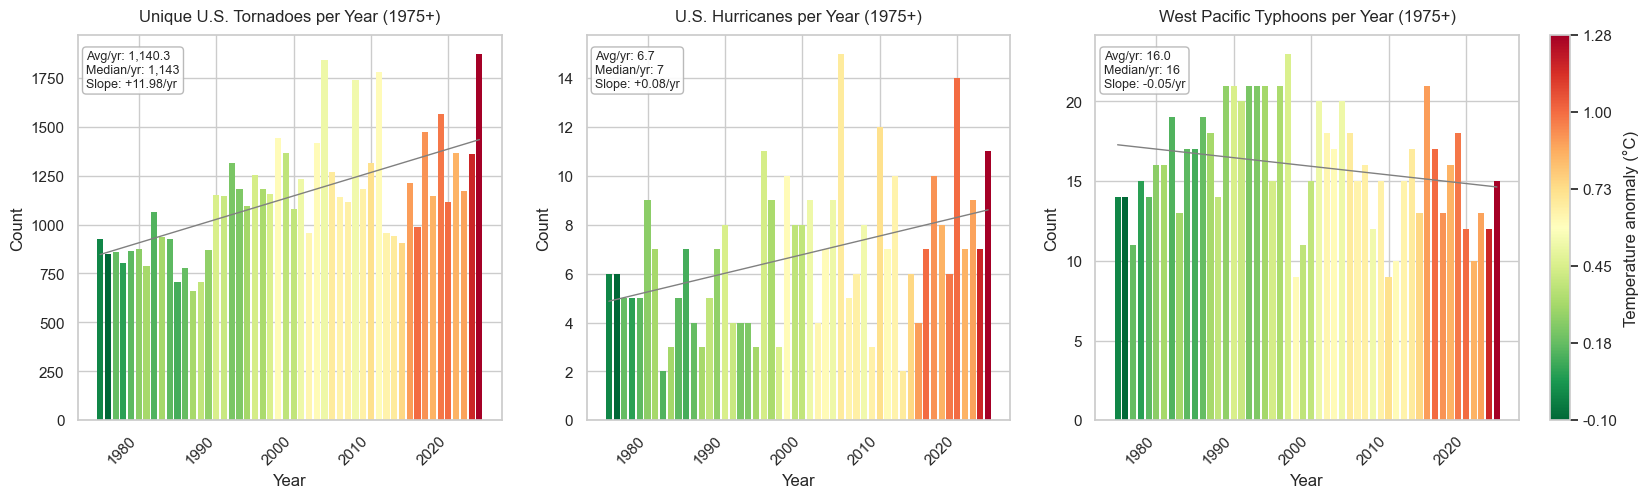

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------- Prep ----------
df = merged.copy().sort_values("Year").reset_index(drop=True)

# Column names (robust to your prefixes)
col_year = "Year"
col_temp = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

series_cols = [
    ("Tornadoes",  "torn_total_tornadoes",  "Unique U.S. Tornadoes"),
    ("Hurricanes", "hurr_total_hurricanes", "U.S. Hurricanes"),
    ("Typhoons",   "typh_total_typhoons",   "West Pacific Typhoons")
]

# Build a long table: Year, Series, Count (keep only available series)
long_parts = []
titles = []  # panel titles matching order
for label, col, nice_title in series_cols:
    if col in df.columns:
        sub = df[[col_year, col]].dropna().rename(columns={col_year: "Year", col: "Count"})
        sub["Series"] = label
        # keep only finite counts
        sub = sub[np.isfinite(sub["Count"])]
        long_parts.append(sub)
        titles.append(nice_title)

if not long_parts:
    raise ValueError("None of the expected series columns were found in `merged`.")

long_df = pd.concat(long_parts, ignore_index=True)

# Temperature map across all years we actually plot
temp_map = df.set_index("Year")[col_temp]
plot_years = np.sort(long_df["Year"].unique())
temp_vals = temp_map.reindex(plot_years).to_numpy(dtype=float)
vmin, vmax = np.nanmin(temp_vals), np.nanmax(temp_vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (temp_vals - vmin) / rng

cmap = sns.color_palette("RdYlGn_r", as_cmap=True)  # green (cool) -> red (warm)
year_to_color = {
    int(y): (cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7))
    for y, t in zip(plot_years, norm_vals)
}

# ---------- Plot (3 facets) ----------
sns.set_theme(style="whitegrid")
n_panels = len(long_parts)
fig, axes = plt.subplots(1, n_panels, figsize=(6*n_panels+2, 5), sharey=False)

if n_panels == 1:
    axes = [axes]

for ax, (label, col, nice_title) in zip(axes, series_cols):
    if col not in df.columns:
        ax.set_visible(False)
        continue

    d = long_df[long_df["Series"] == label].sort_values("Year")
    years = d["Year"].to_numpy()
    counts = d["Count"].to_numpy()

    # Bars colored by temperature anomaly for that year
    colors = [year_to_color[int(y)] for y in years]
    x = np.arange(len(years))
    ax.bar(x, counts, color=colors, edgecolor="none")

    # Trend line (fit vs positions to match bars)
    m, b = np.polyfit(x.astype(float), counts.astype(float), 1)
    y_hat = m * x + b
    ax.plot(x, y_hat, color="gray", lw=1.0, label="Trend")

    # Titles/labels
    ax.set_title(f"{nice_title} per Year (1975+)", pad=10)
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")

    # Decade ticks (display real years while x uses positions)
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)

    # Small stats box
    avg_val = counts.mean()
    med_val = np.median(counts)
    ax.text(0.02, 0.96, f"Avg/yr: {avg_val:,.1f}\nMedian/yr: {med_val:,.0f}\nSlope: {m:+.2f}/yr",
            transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9))

# One shared colorbar for temperature
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.02, fraction=0.05)
cbar.set_label("Temperature anomaly (°C)")
cbar.set_ticks(np.linspace(vmin, vmax, 6))
cbar.set_ticklabels([f"{t:.2f}" for t in np.linspace(vmin, vmax, 6)])

#plt.tight_layout()
norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap)
sm.set_array([])

#cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.9, pad=0.02)
#cbar.set_label("Temperature anomaly (°C)")
#cbar.set_ticks(np.linspace(vmin, vmax, 6))
#cbar.set_ticklabels([f"{t:.2f}" for t in np.linspace(vmin, vmax, 6)])

plt.show()


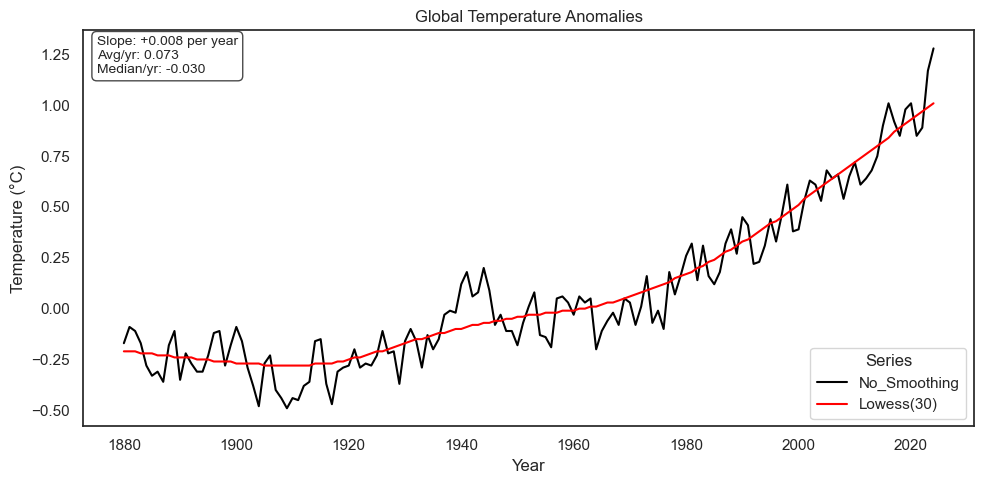

In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read dataset
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
df = pd.read_csv(url)

# Long format for seaborn
df_long = df.melt('Year', var_name='Series', value_name='Temperature')

# Plot
sns.set_theme(style="white")
custom_colors = {'No_Smoothing': 'black', 'Lowess(30)': 'red'}

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=df_long,
    x='Year', y='Temperature',
    hue='Series', style='Series',
    palette=custom_colors, markers=False, dashes=False, ax=ax
)
ax.set(
    ylabel='Temperature (°C)',
    xlabel='Year',
    title='Global Temperature Anomalies'
)

# ---- Stats (from raw No_Smoothing series) ----
raw = df[['Year', 'No_Smoothing']].dropna()
x = raw['Year'].to_numpy(dtype=float)
y = raw['No_Smoothing'].to_numpy(dtype=float)

# Linear slope (°C per year)
m, b = np.polyfit(x, y, 1)
avg = float(np.mean(y))
med = float(np.median(y))

# Optional: show the fitted line (comment out if you don't want it)
# ax.plot(x, m*x + b, color="0.4", lw=1.2, alpha=0.8, label="Trend")

# Stats box
text = (f"Slope: {m:+.3f} per year\n"
        f"Avg/yr: {avg:.3f}\n"
        f"Median/yr: {med:.3f}")
ax.text(
    0.015, 0.985, text,
    transform=ax.transAxes, ha="left", va="top", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", alpha=0.95)
)

plt.tight_layout()
plt.show()


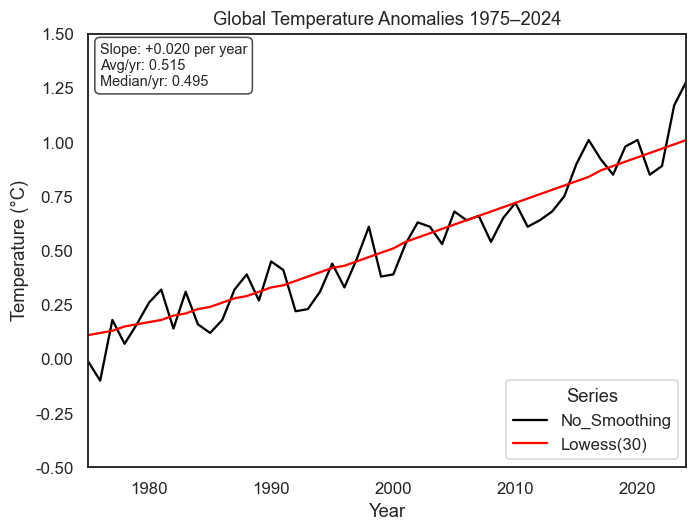

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read + filter
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
df = pd.read_csv(url)
df = df[(df["Year"] >= 1975) & (df["Year"] <= 2024)].copy()

# Long format for seaborn
df_long = df.melt("Year", var_name="Series", value_name="Temperature")

sns.set_theme(style="white")
custom_colors = {"No_Smoothing": "black", "Lowess(30)": "red"}

# 👉 Narrower figure (width ~6.5 inches)
fig, ax = plt.subplots(figsize=(6.5, 5), dpi=110)

import numpy as np
from matplotlib.ticker import FormatStrFormatter

# --- Y-axis: start at -0.25, ticks every 0.25, show two decimals ---
step = 0.25
y_min = -0.50
y_max = np.ceil(df["No_Smoothing"].max() / step) * step  # round up to next 0.25

ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, y_max + step/2, step))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))


sns.lineplot(
    data=df_long, x="Year", y="Temperature",
    hue="Series", style="Series",
    palette=custom_colors, markers=False, dashes=False, ax=ax
)

ax.set(
    ylabel="Temperature (°C)",
    xlabel="Year",
    title="Global Temperature Anomalies 1975–2024"
)
ax.set_xlim(1975, 2024)

# Stats from No_Smoothing
raw = df[["Year", "No_Smoothing"]].dropna()
x = raw["Year"].to_numpy(float)
y = raw["No_Smoothing"].to_numpy(float)
m, b = np.polyfit(x, y, 1)
avg, med = float(np.mean(y)), float(np.median(y))

ax.text(
    0.02, 0.98,
    f"Slope: {m:+.3f} per year\nAvg/yr: {avg:.3f}\nMedian/yr: {med:.3f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", alpha=0.95)
)

plt.tight_layout()
plt.show()


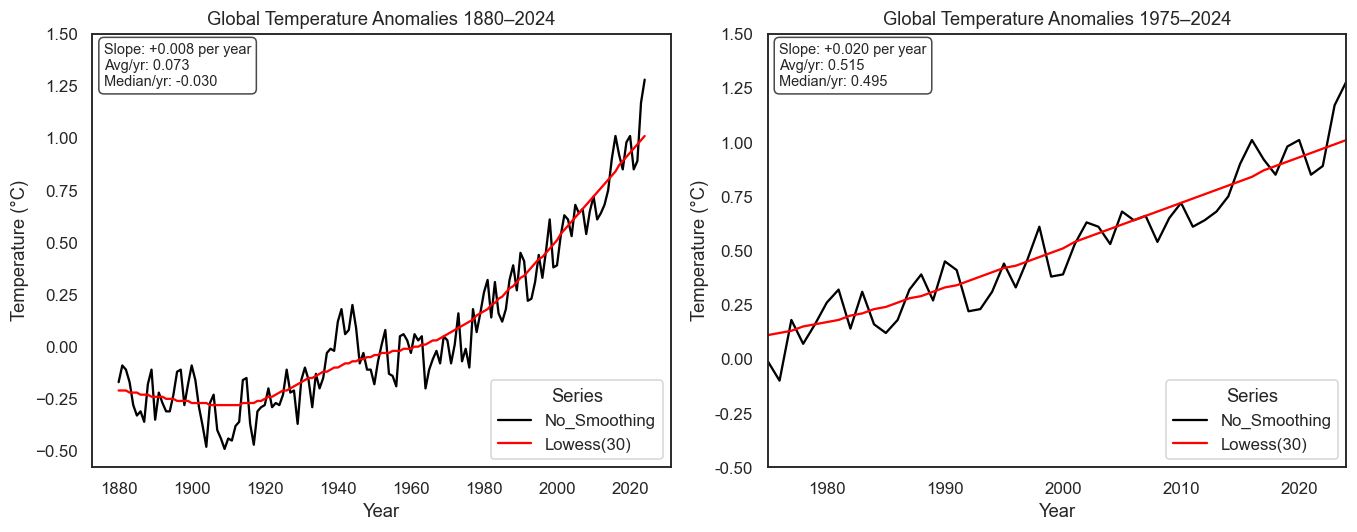

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# --- Read once ---
url = "https://raw.githubusercontent.com/greggmaloy/608/refs/heads/main/assignment_5_temp.csv"
df = pd.read_csv(url)

# Versions of the data
df_filt = df[(df["Year"] >= 1975) & (df["Year"] <= 2024)].copy()

# Long format for seaborn
df_long_full = df.melt("Year", var_name="Series", value_name="Temperature")
df_long_filt = df_filt.melt("Year", var_name="Series", value_name="Temperature")

sns.set_theme(style="white")
custom_colors = {"No_Smoothing": "black", "Lowess(30)": "red"}

# --- Side-by-side figure (reversed order) ---
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12.5, 5), dpi=110)

# ===== LEFT panel: full series 1880–2024 (y max = 1.50) =====
sns.lineplot(
    data=df_long_full, x="Year", y="Temperature",
    hue="Series", style="Series",
    palette=custom_colors, markers=False, dashes=False, ax=ax_left
)
ax_left.set(
    ylabel="Temperature (°C)",
    xlabel="Year",
    title="Global Temperature Anomalies 1880–2024"
)
ax_left.set_ylim(ax_left.get_ylim()[0], 1.50)

# Stats (full period)
raw_full = df[["Year", "No_Smoothing"]].dropna()
xf = raw_full["Year"].to_numpy(float)
yf = raw_full["No_Smoothing"].to_numpy(float)
mf, bf = np.polyfit(xf, yf, 1)
avgf, medf = float(np.mean(yf)), float(np.median(yf))
ax_left.text(
    0.02, 0.98,
    f"Slope: {mf:+.3f} per year\nAvg/yr: {avgf:.3f}\nMedian/yr: {medf:.3f}",
    transform=ax_left.transAxes, ha="left", va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", alpha=0.95)
)

# ===== RIGHT panel: 1975–2024 with custom y ticks =====
sns.lineplot(
    data=df_long_filt, x="Year", y="Temperature",
    hue="Series", style="Series",
    palette=custom_colors, markers=False, dashes=False, ax=ax_right
)
ax_right.set(
    ylabel="Temperature (°C)",
    xlabel="Year",
    title="Global Temperature Anomalies 1975–2024"
)
ax_right.set_xlim(1975, 2024)

# Y-axis: start at -0.50, ticks every 0.25, two decimals
step = 0.25
y_min = -0.50
y_max = np.ceil(df_filt["No_Smoothing"].max() / step) * step
ax_right.set_ylim(y_min, y_max)
ax_right.set_yticks(np.arange(y_min, y_max + step/2, step))
ax_right.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Stats (filtered period)
raw = df_filt[["Year", "No_Smoothing"]].dropna()
x = raw["Year"].to_numpy(float)
y = raw["No_Smoothing"].to_numpy(float)
m, b = np.polyfit(x, y, 1)
avg, med = float(np.mean(y)), float(np.median(y))
ax_right.text(
    0.02, 0.98,
    f"Slope: {m:+.3f} per year\nAvg/yr: {avg:.3f}\nMedian/yr: {med:.3f}",
    transform=ax_right.transAxes, ha="left", va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.25", alpha=0.95)
)

plt.tight_layout()
plt.show()


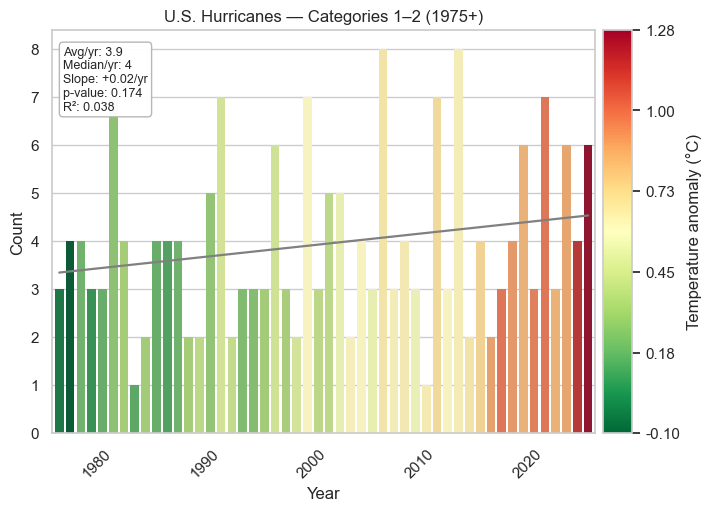

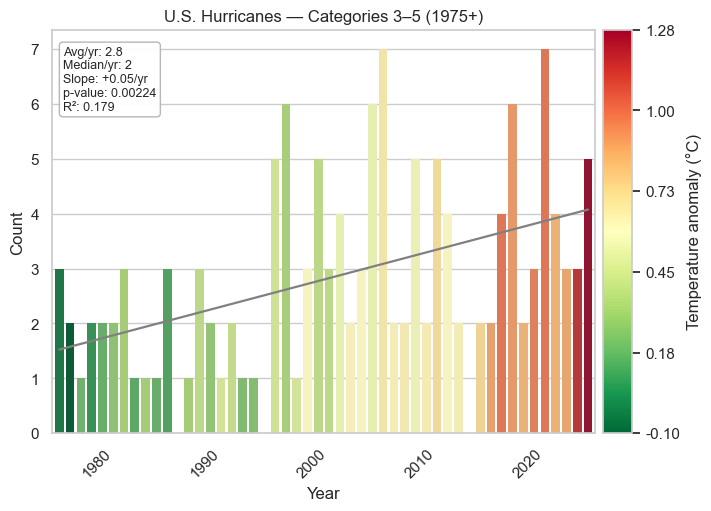

In [77]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---------- Prep ----------
df = merged.copy().sort_values("Year").reset_index(drop=True)

col_year = "Year"
col_temp = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

# Find hurricane category columns (supports hurr_cat_* or Cat_*)
cat_cols = {}
for k in range(1, 6):
    if f"hurr_cat_{k}" in df.columns:
        cat_cols[k] = f"hurr_cat_{k}"
    elif f"Cat_{k}" in df.columns:
        cat_cols[k] = f"Cat_{k}"
    else:
        raise KeyError(f"Missing hurricane category column for Cat {k}.")

# Temperature → continuous colors (Seaborn cmap, Matplotlib for colorbar)
temp_map  = df.set_index(col_year)[col_temp]
plot_years = np.sort(df[col_year].dropna().unique())
vals = temp_map.reindex(plot_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (vals - vmin) / rng
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): (cmap(t) if np.isfinite(t) else (0.7,0.7,0.7))
                 for y, t in zip(plot_years, norm_vals)}

sns.set_theme(style="whitegrid")

# ---------- Build combined series ----------
def combined_counts(df, col_year, cols_to_sum, label):
    d = df[[col_year] + cols_to_sum].dropna(subset=[col_year]).copy()
    d = d.sort_values(col_year)
    d["Count"] = d[cols_to_sum].sum(axis=1)
    out = d[[col_year, "Count"]].rename(columns={col_year: "Year"})
    out["Group"] = label
    out["Temp"] = out["Year"].map(temp_map)  # for potential future use
    return out

cat12_cols = [cat_cols[1], cat_cols[2]]
cat35_cols = [cat_cols[3], cat_cols[4], cat_cols[5]]

d12 = combined_counts(df, col_year, cat12_cols, "Cat 1–2")
d35 = combined_counts(df, col_year, cat35_cols, "Cat 3–5")

# ---------- Helper to plot one Seaborn bar chart ----------
def plot_group_seaborn(d, title, vmin, vmax, cmap):
    years  = d["Year"].to_numpy(int)
    counts = d["Count"].to_numpy(float)
    x = np.arange(len(years))

    # ↓ narrower: was (12, 5). Try (7, 5) or (6, 5).
    fig = plt.figure(figsize=(7, 5), constrained_layout=True)
    gs = fig.add_gridspec(nrows=1, ncols=20)
    ax = fig.add_subplot(gs[0, :19])
    cax = fig.add_subplot(gs[0, 19])

    pal = {int(y): year_to_color[int(y)] for y in years}
    sns.barplot(
        data=pd.DataFrame({"Year": years, "Count": counts}),
        x="Year", y="Count",
        hue="Year", palette=pal, dodge=False, ax=ax, edgecolor=None, linewidth=0
    )
    if ax.get_legend() is not None:
        ax.legend_.remove()

    m = np.nan; b = np.nan; p = np.nan; r2 = np.nan
    mask = np.isfinite(counts)
    if mask.sum() >= 2 and np.nanstd(counts) > 0:
        res = linregress(x[mask].astype(float), counts[mask].astype(float))
        m, b, p, r2 = res.slope, res.intercept, res.pvalue, res.rvalue**2
        ax.plot(x, m * x + b, color="gray", lw=1.6)

    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)

    # optional: a touch less side padding on a narrow figure
    ax.margins(x=0.005)

    avg_val = np.nanmean(counts)
    med_val = np.nanmedian(counts)
    ax.text(
        0.02, 0.96,
        f"Avg/yr: {avg_val:,.1f}\n"
        f"Median/yr: {med_val:,.0f}\n"
        f"Slope: {m:+.2f}/yr\n"
        f"p-value: {p:.3g}\n"
        f"R²: {r2:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95)
    )

    norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Temperature anomaly (°C)")
    ticks = np.linspace(vmin, vmax, 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

    plt.show()

# ---------- Render the two Seaborn figures ----------
plot_group_seaborn(d12, "U.S. Hurricanes — Categories 1–2 (1975+)", vmin, vmax, cmap)
plot_group_seaborn(d35, "U.S. Hurricanes — Categories 3–5 (1975+)", vmin, vmax, cmap)


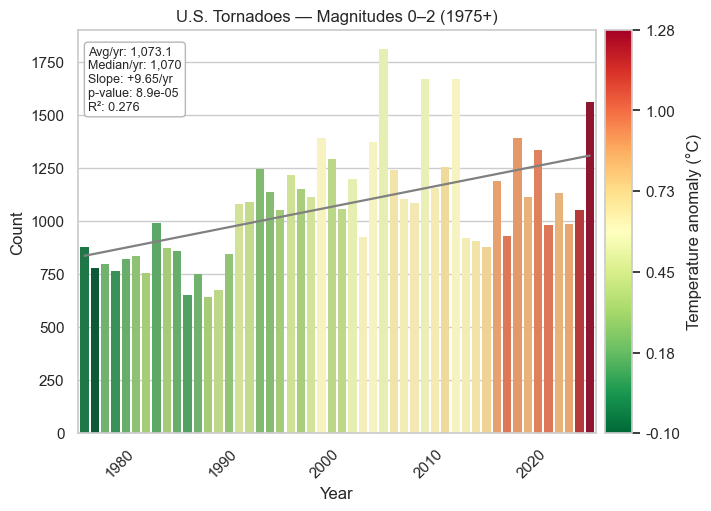

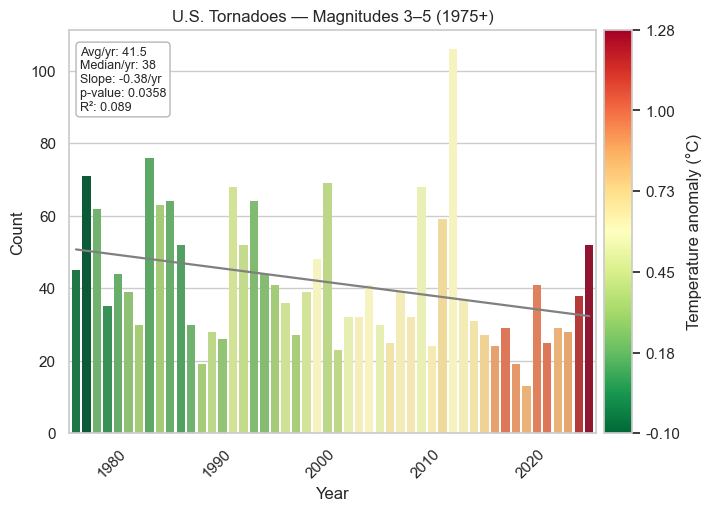

In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ===== Prep from merged =====
df = merged.copy().sort_values("Year").reset_index(drop=True)

year_col = "Year"
temp_col = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

# Find tornado magnitude columns (robust to your naming)
mag_cols = []
for k in range(6):  # 0..5
    if f"torn_mag{k}" in df.columns:
        mag_cols.append((k, f"torn_mag{k}"))
    elif f"Mag{k}" in df.columns:
        mag_cols.append((k, f"Mag{k}"))
    else:
        raise KeyError(f"Missing tornado magnitude column for Mag {k}.")
mag_map = dict(mag_cols)

# Temperature → color per year
temp_map = df.set_index(year_col)[temp_col]
plot_years = np.sort(df[year_col].dropna().unique())
vals = temp_map.reindex(plot_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (vals - vmin) / rng
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): (cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7))
                 for y, t in zip(plot_years, norm_vals)}

sns.set_theme(style="whitegrid")

# --- helper: sum selected magnitude columns into a single yearly series ---
def combined_counts(df, year_col, cols_to_sum, label):
    d = df[[year_col] + cols_to_sum].dropna(subset=[year_col]).copy()
    d = d.sort_values(year_col)
    d["Count"] = d[cols_to_sum].sum(axis=1)
    out = d[[year_col, "Count"]].rename(columns={year_col: "Year"})
    out["Group"] = label
    return out

# Groups: 0–2 and 3–5
low_cols  = [mag_map[k] for k in (0, 1, 2)]
high_cols = [mag_map[k] for k in (3, 4, 5)]
d_low  = combined_counts(df, year_col, low_cols,  "Mag 0–2")
d_high = combined_counts(df, year_col, high_cols, "Mag 3–5")

# --- plotting helper (narrower figure) ---
def plot_group_seaborn(d, title, vmin, vmax, cmap):
    years  = d["Year"].to_numpy(int)
    counts = d["Count"].to_numpy(float)
    x = np.arange(len(years))

    # a bit narrower than default
    fig = plt.figure(figsize=(7, 5), constrained_layout=True)
    gs = fig.add_gridspec(nrows=1, ncols=20)  # reserve a slim column for colorbar
    ax  = fig.add_subplot(gs[0, :19])
    cax = fig.add_subplot(gs[0, 19])

    # Map each year to its temp-based color via seaborn palette
    pal = {int(y): year_to_color[int(y)] for y in years}
    data = pd.DataFrame({"Year": years, "Count": counts})
    sns.barplot(
        data=data, x="Year", y="Count",
        hue="Year", palette=pal, dodge=False, ax=ax,
        edgecolor=None, linewidth=0
    )
    # remove large legend
    if ax.get_legend() is not None:
        ax.legend_.remove()

    # Trendline on bar indices (aligns visually with bars)
    m = np.nan; b = np.nan; p = np.nan; r2 = np.nan
    mask = np.isfinite(counts)
    if mask.sum() >= 2 and np.nanstd(counts[mask]) > 0:
        res = linregress(x[mask].astype(float), counts[mask].astype(float))
        m, b, p, r2 = res.slope, res.intercept, res.pvalue, res.rvalue**2
        ax.plot(x, m * x + b, color="gray", lw=1.6)

    # Labels & ticks
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)
    ax.margins(x=0.005)

    # Stats box
    avg_val = np.nanmean(counts)
    med_val = np.nanmedian(counts)
    ax.text(
        0.02, 0.96,
        f"Avg/yr: {avg_val:,.1f}\n"
        f"Median/yr: {med_val:,.0f}\n"
        f"Slope: {m:+.2f}/yr\n"
        f"p-value: {p:.3g}\n"
        f"R²: {r2:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95)
    )

    # Continuous colorbar for temperature
    norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Temperature anomaly (°C)")
    ticks = np.linspace(vmin, vmax, 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

    plt.show()

# --- render the two figures ---
plot_group_seaborn(d_low,  "U.S. Tornadoes — Magnitudes 0–2 (1975+)", vmin, vmax, cmap)
plot_group_seaborn(d_high, "U.S. Tornadoes — Magnitudes 3–5 (1975+)", vmin, vmax, cmap)


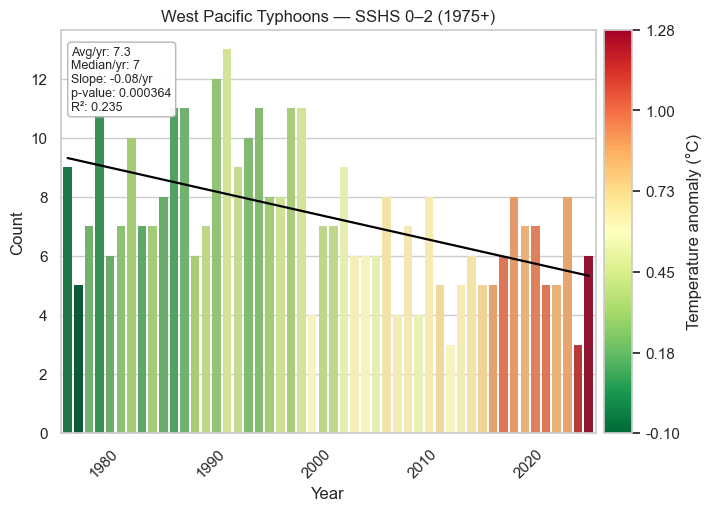

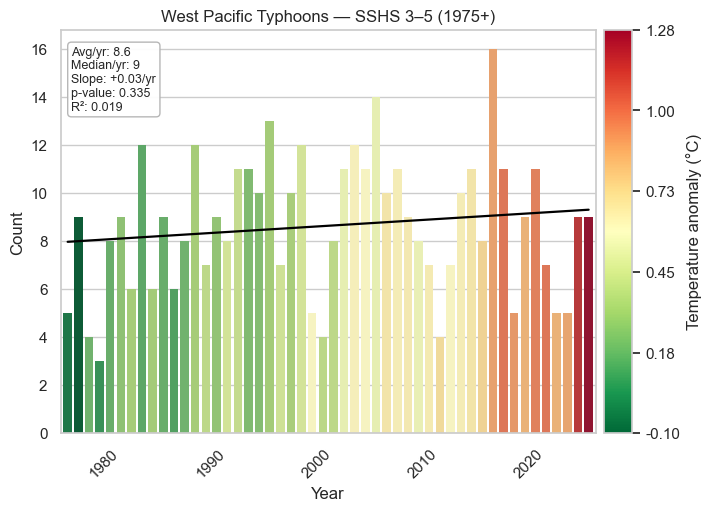

In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ===== Prep from merged =====
df = merged.copy().sort_values("Year").reset_index(drop=True)

year_col = "Year"
temp_col = "temp_no_smoothing" if "temp_no_smoothing" in df.columns else "No_Smoothing"

# Find typhoon SSHS category columns (robust to your naming)
typh_cols = []
for k in range(6):  # 0..5
    if f"typh_cat{k}" in df.columns:
        typh_cols.append((k, f"typh_cat{k}"))
    elif f"Cat{k}" in df.columns:
        typh_cols.append((k, f"Cat{k}"))
    else:
        raise KeyError(f"Missing typhoon category column for Cat {k}.")
typh_map = dict(typh_cols)

# Temperature → color per year
temp_map = df.set_index(year_col)[temp_col]
plot_years = np.sort(df[year_col].dropna().unique())
vals = temp_map.reindex(plot_years).to_numpy(float)
vmin, vmax = np.nanmin(vals), np.nanmax(vals)
rng = (vmax - vmin) if vmax > vmin else 1.0
norm_vals = (vals - vmin) / rng
cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
year_to_color = {int(y): (cmap(t) if np.isfinite(t) else (0.7, 0.7, 0.7))
                 for y, t in zip(plot_years, norm_vals)}

sns.set_theme(style="whitegrid")

# --- helper: sum selected category columns into one yearly series ---
def combined_counts(df, year_col, cols_to_sum, label):
    d = df[[year_col] + cols_to_sum].dropna(subset=[year_col]).copy()
    d = d.sort_values(year_col)
    d["Count"] = d[cols_to_sum].sum(axis=1)
    out = d[[year_col, "Count"]].rename(columns={year_col: "Year"})
    out["Group"] = label
    return out

# Groups: 0–2 and 3–5
low_cols  = [typh_map[k] for k in (0, 1, 2)]
high_cols = [typh_map[k] for k in (3, 4, 5)]
d_low  = combined_counts(df, year_col, low_cols,  "SSHS 0–2")
d_high = combined_counts(df, year_col, high_cols, "SSHS 3–5")

# --- plotting helper (narrower figure) ---
def plot_group_seaborn(d, title, vmin, vmax, cmap):
    years  = d["Year"].to_numpy(int)
    counts = d["Count"].to_numpy(float)
    x = np.arange(len(years))

    fig = plt.figure(figsize=(7, 5), constrained_layout=True)  # narrower width
    gs = fig.add_gridspec(nrows=1, ncols=20)  # slim colorbar at the right
    ax  = fig.add_subplot(gs[0, :19])
    cax = fig.add_subplot(gs[0, 19])

    # Bars colored by temperature via palette mapping Year → color
    pal = {int(y): year_to_color[int(y)] for y in years}
    data = pd.DataFrame({"Year": years, "Count": counts})
    sns.barplot(
        data=data, x="Year", y="Count",
        hue="Year", palette=pal, dodge=False, ax=ax,
        edgecolor=None, linewidth=0
    )
    if ax.get_legend() is not None:
        ax.legend_.remove()

    # Trendline on bar indices (aligns visually with bars)
    m = np.nan; b = np.nan; p = np.nan; r2 = np.nan
    mask = np.isfinite(counts)
    if mask.sum() >= 2 and np.nanstd(counts[mask]) > 0:
        res = linregress(x[mask].astype(float), counts[mask].astype(float))
        m, b, p, r2 = res.slope, res.intercept, res.pvalue, res.rvalue**2
        ax.plot(x, m * x + b, color="black", lw=1.6)

    # Labels & ticks
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.set_xlabel("Year")
    decade_pos = [i for i, y in enumerate(years) if (y >= 1980 and y % 10 == 0)]
    ax.set_xticks(decade_pos)
    ax.set_xticklabels([str(int(years[i])) for i in decade_pos], rotation=45, ha="right")
    ax.set_ylim(bottom=0)
    ax.margins(x=0.005)

    # Stats box
    avg_val = np.nanmean(counts)
    med_val = np.nanmedian(counts)
    ax.text(
        0.02, 0.96,
        f"Avg/yr: {avg_val:,.1f}\n"
        f"Median/yr: {med_val:,.0f}\n"
        f"Slope: {m:+.2f}/yr\n"
        f"p-value: {p:.3g}\n"
        f"R²: {r2:.3f}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.95)
    )

    # Continuous colorbar for temperature
    norm_mpl = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm_mpl, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Temperature anomaly (°C)")
    ticks = np.linspace(vmin, vmax, 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

    plt.show()

# --- render the two figures ---
plot_group_seaborn(d_low,  "West Pacific Typhoons — SSHS 0–2 (1975+)", vmin, vmax, cmap)
plot_group_seaborn(d_high, "West Pacific Typhoons — SSHS 3–5 (1975+)", vmin, vmax, cmap)
